# Graph Neural Network

### Load Libraries

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import torch.optim as optim
from torch.utils.data import TensorDataset, random_split
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import seaborn as sns
import matplotlib.pyplot as plt
import os
import joblib
import sys

from tqdm import tqdm
import optuna
from optuna.samplers import TPESampler

# Set up device (is available use GPU to speed up computations)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

os.chdir("/home/jovyan/ds-project-2025/code/model")
print("Current working directory:", os.getcwd())

# Add code directory to path to import src
# Assuming structure: .../code/model/gnn.ipynb
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
# Or if running from root, append 'code'
if os.path.exists("code"):
    sys.path.append("code")


from src.data import (
    create_graph_data_dict,
    get_graph_data_loaders,
    normalize_graph_data,
)
from src.training import EarlyStopping, train_model
from src.evaluation import evaluation, evaluate_gnn

cuda
Current working directory: /home/jovyan/ds-project-2025/code/model


## Load Data

In [14]:
# Load graph data using the new create_graph_data_dict function
# This function handles:
# - Loading embeddings from individual year files
# - Creating edgelist from database (with temporal features)
# - Computing node scalar features (5 features)
# - Computing edge features (6 features)
# - Using next year's score as target (no data leakage)

train_years = list(range(2006, 2016))  # 10 years
val_years = list(range(2016, 2019))  # 3 years
test_years = list(range(2019, 2023))  # 4 years

data_dict = create_graph_data_dict(
    data_folder="../data/ipc_mean_year_abstract",
    db_path="../data/patent.db",
    score_type="rel",
)

data_dict, norm_stats = normalize_graph_data(data_dict, train_years)  # <-- add this

train_loader, val_loader, test_loader = get_graph_data_loaders(
    data_dict, train_years, val_years, test_years
)
print(f"Loaded data for {len(data_dict)} years: {sorted(data_dict.keys())}")

Calculating popularity scores...
Creating global IPC mapping...
Total unique IPC codes: 1989
Creating edgelist with Salton similarity...


Processing years for graph: 100%|██████████| 17/17 [00:16<00:00,  1.02it/s]


Normalization fitted on 10 training year(s).
  count   mean=[83.68548583984375, 73.51998901367188], std=[129.19459533691406, 126.07595825195312]
  weight  mean=[4.297879695892334, 3.2306504249572754, 0.1480749249458313], std=[11.441514015197754, 11.152114868164062, 4.799782752990723]
Train graphs: 10
Validation graphs: 3
Test graphs: 4
Loaded data for 17 years: [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]


In [15]:
# Check the structure of one year's data
sample_year = 2008
print(f"Data for year {sample_year}:")
print(data_dict[sample_year])
print(f"Node embeddings shape: {data_dict[sample_year].x.shape}")
print(f"Node scalar features shape: {data_dict[sample_year].scalar.shape}")
print(f"Edge index shape: {data_dict[sample_year].edge_index.shape}")
print(f"Edge attributes shape: {data_dict[sample_year].edge_attr.shape}")
print(f"Target shape: {data_dict[sample_year].y.shape}")

Data for year 2008:
Data(x=[934, 1024], edge_index=[2, 13607], edge_attr=[13607, 6], y=[934], scalar=[934, 12], year=[934])
Node embeddings shape: torch.Size([934, 1024])
Node scalar features shape: torch.Size([934, 12])
Edge index shape: torch.Size([2, 13607])
Edge attributes shape: torch.Size([13607, 6])
Target shape: torch.Size([934])


In [3]:
data_dict[2006]

Data(x=[841, 1024], edge_index=[2, 11759], edge_attr=[11759, 6], y=[841], scalar=[841, 12], year=[841])

In [4]:
data_dict[2006].scalar[0]

tensor([-0.4223, -0.5996,  0.0000, -0.6568,  1.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000])

In [5]:
data_dict[2006].y

tensor([ 0.5550,  0.0625, -0.1431, -0.4418, -0.0533, -0.0435,  0.0377,  0.1991,
        -0.0426,  0.1292, -0.5232, -0.2578, -0.1591, -0.0328, -0.0370, -0.1509,
        -0.0455, -0.1978, -0.3448,  0.4595, -0.2744, -0.3137, -0.0426, -0.6729,
        -0.3102,  0.4480,  0.2076, -0.4769, -0.0317,  0.4125, -0.7577, -0.2211,
         0.3932,  0.3497,  0.3754,  0.2384,  0.3228,  0.5167,  0.0579,  0.5623,
         0.2274, -0.0770,  0.1252,  0.2021,  0.5953,  0.5199,  0.1226, -0.6931,
         0.1335,  0.1699,  0.0257,  0.4643, -0.2412, -0.2469,  0.0052,  0.0262,
         0.1195, -0.0265,  0.1061,  0.2392, -0.2007,  0.3732, -0.1077,  0.1493,
        -0.0827,  0.2877, -0.1246,  0.1967,  0.2917,  0.1155,  0.1178, -0.0339,
         0.1133,  0.1529, -0.0455,  0.0502,  0.1431, -0.0198,  0.1120, -0.0749,
        -0.1304,  0.0465, -0.1257,  0.0255, -0.1464, -0.1881, -0.0369,  0.0572,
        -0.1833,  0.2683,  0.0000, -0.0494,  0.0086,  0.1125, -0.0548, -0.2686,
         0.2942,  0.1773,  0.2318,  0.46

## Model Definition

In [ ]:
# create graph attention network model
class GATNet(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        scalar_dim,
        hidden_channels=64,
        heads=4,
        dropout=0.2,
        task_type="regression",
    ):
        """
        Graph Attention Network with scalar features combined at both beginning and end.

        Args:
            in_channels: Dimension of node embeddings (e.g., 1024)
            out_channels: Output dimension of final GNN layer
            scalar_dim: Number of scalar features per node (automatically detected from data)
            hidden_channels: Hidden dimension for GNN layers
            heads: Number of attention heads
            dropout: Dropout rate
            task_type: 'regression' or 'classification'
        """
        super(GATNet, self).__init__()
        self.task_type = task_type
        self.scalar_dim = scalar_dim

        # CHANGE: Concatenate scalars with embeddings at the BEGINNING
        # Input to first GNN layer is now: embeddings + scalars (e.g., 1024 + 5 = 1029)
        self.conv1 = GATv2Conv(
            in_channels + scalar_dim,  # Input includes both embeddings and scalars
            hidden_channels,
            heads=heads,
            edge_dim=6,
            dropout=dropout,
            add_self_loops=True,
        )
        self.conv2 = GATv2Conv(
            hidden_channels * heads,
            out_channels,
            heads=1,
            concat=False,
            edge_dim=6,
            dropout=dropout,
            add_self_loops=True,
        )
        self.dropout = dropout

        # Final MLP combining GNN output with scalar features AGAIN
        # This allows the model to use scalar features at multiple stages
        self.final_mlp = nn.Sequential(
            nn.Linear(out_channels, 1024),  # Automatically uses scalar_dim
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(
                64, 1
            ),  # Output layer: 1 value for both regression and classification (logits)
        )

    def forward(self, data):
        x, edge_index, edge_attr, scalar = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.scalar,
        )

        x = torch.cat([x, scalar], dim=1)

        # GNN layers with edge attributes
        x = self.conv1(x, edge_index, edge_attr=edge_attr)
        # x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index, edge_attr=edge_attr)

        # Pass through final MLP
        output = self.final_mlp(x)

        return output

## Training Setup

## Training Loop

In [6]:
# Assign years sequentially to train, validation, and test sets
train_years: list = range(2006, 2016)
validation_years: list = range(2016, 2019)
test_years: list = range(2019, 2023)

train_loader, val_loader, test_loader = get_graph_data_loaders(
    data_dict, train_years, validation_years, test_years, batch_size=1
)

Train graphs: 10
Validation graphs: 3
Test graphs: 3


### Overfit Test

In [7]:
# Verify data structure before overfit test
print(f"Number of node features (embeddings): {data_dict[2006].num_node_features}")
print(f"Number of scalar features: {data_dict[2006].scalar.shape[1]}")
print(f"Number of edge features: {data_dict[2006].edge_attr.shape[1]}")
print(f"Total features the model will use:")
print(f"  - Node embeddings: {data_dict[2006].num_node_features}")
print(f"  - Node scalars: {data_dict[2006].scalar.shape[1]}")
print(f"  - Edge features: {data_dict[2006].edge_attr.shape[1]}")

Number of node features (embeddings): 1024
Number of scalar features: 12
Number of edge features: 6
Total features the model will use:
  - Node embeddings: 1024
  - Node scalars: 12
  - Edge features: 6


In [ ]:
# Use only one year for overfitting (2015 has both features and target)
overfit_loader, _, _ = get_graph_data_loaders(
    data_dict,
    train_years=[2015],  # Single year
    val_years=[2015],  # Same year for validation
    test_years=[2015],  # Same year for test
    batch_size=1,  # Single graph per batch
)

print(f"Overfit loader: {len(overfit_loader)} batch(es)")

# Model hyperparameters (smaller for faster testing)
in_channels = data_dict[2006].num_node_features  # 1024 embeddings
scalar_dim = data_dict[2006].scalar.shape[
    1
]  # Automatically detect number of scalar features
out_channels = 32  # Reduced from typical values for faster training
hidden_channels = 64  # Reduced from 128 for faster training
heads = 2  # Reduced from 4 for faster training
dropout = 0.0  # No dropout for overfitting
learning_rate = 0.001  # Higher LR for faster convergence

# Initialize model
overfit_model = GATNet(
    in_channels, out_channels, scalar_dim, hidden_channels, heads, dropout
).to(device)
optimizer = optim.Adam(overfit_model.parameters(), lr=learning_rate)
criterion = nn.MSELoss().to(device)

# Early stopping with high patience for overfit test
early_stopper = EarlyStopping(
    patience=50,  # Allow more epochs before stopping
    min_delta=0.0001,
    path="gnn_overfit_test.pt",
    printing=True,
)

# Train for limited epochs
train_model(
    200,  # epochs (positional argument)
    overfit_model,
    optimizer,
    criterion,
    overfit_loader,  # train_loader
    overfit_loader,  # val_loader (same data)
    early_stopper,
    device,
    printing=True,  # Print every epoch
)

OVERFIT TEST - Pipeline Verification
Goal: Verify that the model can overfit a small dataset
Expected: Loss should decrease rapidly to near 0
Train graphs: 1
Validation graphs: 1
Test graphs: 1
Overfit loader: 1 batch(es)
Model Configuration:
  Input channels (embeddings): 1024
  Scalar features: 12
  Total input to GNN: 1036
  Output channels: 32
Removing existing model at: gnn_overfit_test.pt
Starting overfit test for 100 epochs...
If loss decreases significantly, the pipeline is working!
Epoch 1/200, Train Loss: 0.1437, Val Loss: 0.1513
Validation loss decreased (0.151324 --> 0.151324).  Saving model ...
Epoch 2/200, Train Loss: 0.1517, Val Loss: 0.1413
Validation loss decreased (0.151324 --> 0.141296).  Saving model ...
Epoch 3/200, Train Loss: 0.1411, Val Loss: 0.1416
Epoch 4/200, Train Loss: 0.1419, Val Loss: 0.1390
Validation loss decreased (0.141296 --> 0.139009).  Saving model ...
Epoch 5/200, Train Loss: 0.1397, Val Loss: 0.1371
Validation loss decreased (0.139009 --> 0.13708

In [10]:
evaluate_gnn(
    overfit_model,
    overfit_loader,
    device,
    compare_baselines=True,
    data_dict=data_dict,
    test_years=[2015],
    export=True,
)

### Single Setup Training

Removing existing model at: best_gat_reg_model.pt
Epoch 1/500, Train Loss: 0.2387, Val Loss: 0.2184
Validation loss decreased (0.218394 --> 0.218394).  Saving model ...
Epoch 2/500, Train Loss: 0.2365, Val Loss: 0.2167
Validation loss decreased (0.218394 --> 0.216660).  Saving model ...
Epoch 3/500, Train Loss: 0.2372, Val Loss: 0.2184
Epoch 4/500, Train Loss: 0.2359, Val Loss: 0.2156
Validation loss decreased (0.216660 --> 0.215562).  Saving model ...
Epoch 5/500, Train Loss: 0.2341, Val Loss: 0.2208
Epoch 6/500, Train Loss: 0.2360, Val Loss: 0.2163
Epoch 7/500, Train Loss: 0.2345, Val Loss: 0.2169
Epoch 8/500, Train Loss: 0.2334, Val Loss: 0.2171
Epoch 9/500, Train Loss: 0.2335, Val Loss: 0.2155
Validation loss decreased (0.215562 --> 0.215454).  Saving model ...
Epoch 10/500, Train Loss: 0.2327, Val Loss: 0.2167
Epoch 11/500, Train Loss: 0.2315, Val Loss: 0.2162
Epoch 12/500, Train Loss: 0.2297, Val Loss: 0.2157
Epoch 13/500, Train Loss: 0.2281, Val Loss: 0.2163
Epoch 14/500, Train 

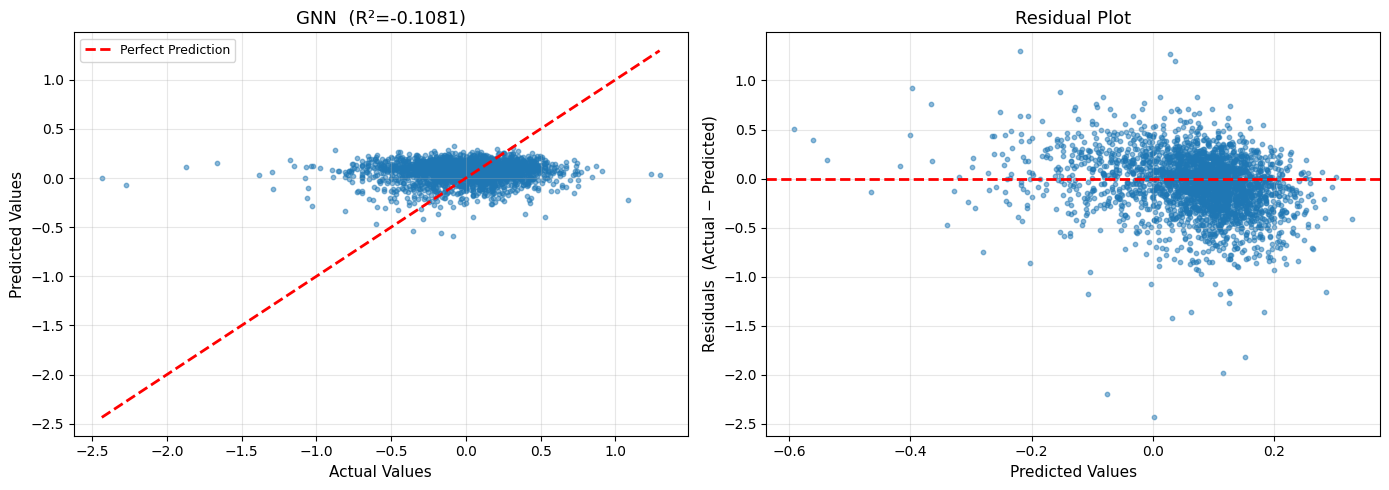

In [7]:
# training parameters
in_channels = data_dict[2006].num_node_features
scalar_dim = data_dict[2006].scalar.shape[1]  # Automatically detect scalar features
out_channels = 512
hidden_channels = 512
heads = 6
dropout = 0.1
learning_rate = 0.0001

model = GATNet(
    in_channels, out_channels, scalar_dim, hidden_channels, heads, dropout
).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# CHANGED: Use MarginRankingLoss
# margin=1.0 ensures the model tries to push the score of the better rank
# at least 1.0 points higher than the worse rank.
# criterion = nn.MSELoss().to(device)
criterion = nn.L1Loss().to(device)

# Updated path to avoid overwriting your classification model
early_stopper = EarlyStopping(
    patience=50, min_delta=0.0001, path="best_gat_reg_model.pt", printing=True
)

# CHANGED: Call the ranking training loop
train_model(
    500,
    model,
    optimizer,
    criterion,
    train_loader,
    val_loader,
    early_stopper,
    device,
    printing=True,
)

all_outputs, all_targets, avg_correct = evaluation(
    model, val_loader, device, printing=True
)


MODEL: GNN
Number of predictions:            2802
Mean Squared Error (MSE):         0.095618
Root Mean Squared Error (RMSE):   0.309222
Mean Absolute Error (MAE):        0.226996
Median Absolute Error:            0.173826
Mean Absolute Percentage Error:   27377611.62%
R² Score:                         -0.108060

BASELINE: Previous Year's Score (Persistence)
Number of predictions:            2732
Mean Squared Error (MSE):         0.217203
Root Mean Squared Error (RMSE):   0.466051
Mean Absolute Error (MAE):        0.356524
Median Absolute Error:            0.277632
Mean Absolute Percentage Error:   62156973.52%
R² Score:                         -1.708375

BASELINE: Overall Mean (Global Historical Mean)
Number of predictions:            2802
Mean Squared Error (MSE):         0.087550
Root Mean Squared Error (RMSE):   0.295889
Mean Absolute Error (MAE):        0.223312
Median Absolute Error:            0.179437
Mean Absolute Percentage Error:   7058776.99%
R² Score:                      

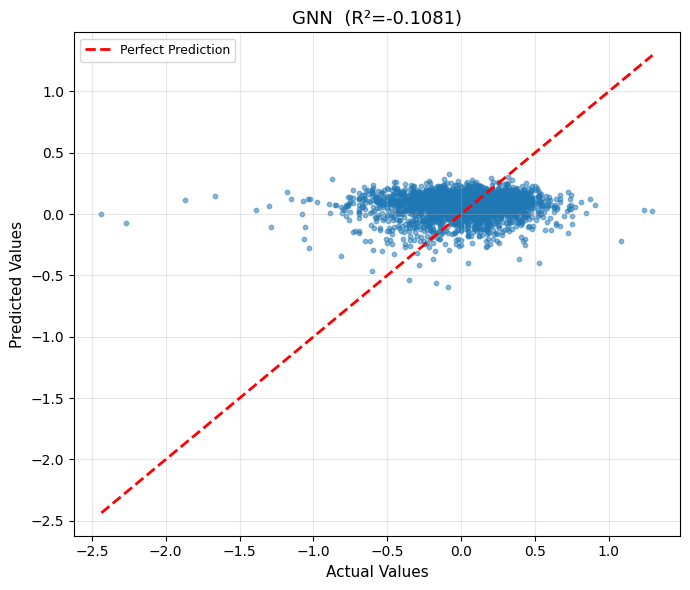

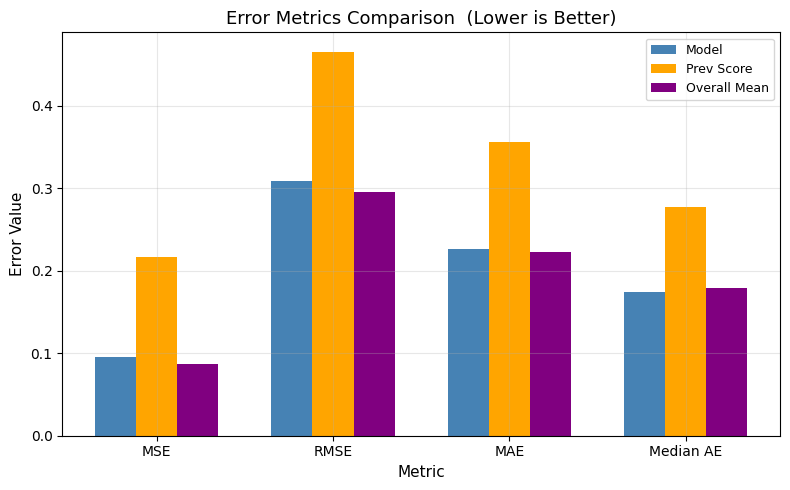

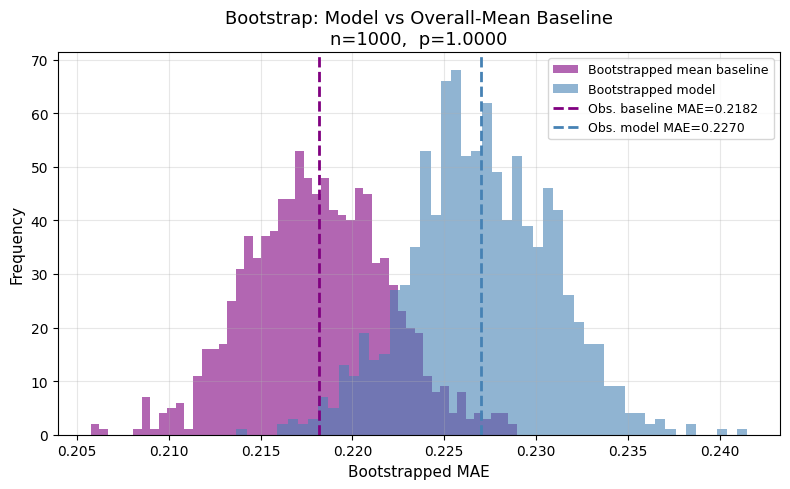

{'model': {'predictions': array([-0.13389347, -0.12658507, -0.10877335, ...,  0.10364608,
          0.08846103,  0.0845509 ], shape=(2802,), dtype=float32),
  'targets': array([ 0.        , -0.22957444, -0.4567584 , ..., -0.12136085,
          0.08494068,  0.27369583], shape=(2802,), dtype=float32),
  'years': array([2018, 2018, 2018, ..., 2019, 2019, 2019], shape=(2802,)),
  'metrics': {'mse': 0.09561825666020139,
   'rmse': 0.30922201839487656,
   'mae': 0.22699606424118782,
   'mape': 27377611.621762004,
   'r2': -0.10806021390542697,
   'median_ae': 0.17382581904530525}},
 'prev_score_baseline': {'predictions': array([ 0.4054651 ,  0.27958485,  0.52129692, ...,  0.15874839,
         -0.02640417, -0.23732819], shape=(2732,)),
  'targets': array([ 0.        , -0.22957444, -0.45675841, ..., -0.12136085,
          0.08494068,  0.27369583], shape=(2732,)),
  'metrics': {'mse': 0.21720345438821054,
   'rmse': 0.4660509139441854,
   'mae': 0.3565237232124962,
   'mape': 62156973.52007553,

In [8]:
evaluate_gnn(
    model,
    val_loader,
    device,
    compare_baselines=True,
    data_dict=data_dict,
    test_years=val_years,
    export=True,
)

### Hyperparameter Tuning Optuna

Starting Optuna search: 30 trials, up to 150 epochs each.


  0%|          | 0/30 [00:00<?, ?it/s]

/home/jovyan/environments/dsp/lib/python3.11/site-packages/optuna/distributions.py:684: UserWarning: The distribution is specified by [16, 512] and step=64, but the range is not divisible by `step`. It will be replaced with [16, 464].
  warnings.warn(



Best trial: #7  (val loss = 0.226571)
Best hyperparameters:
  hidden_channels     : 16
  out_channels        : 512
  heads               : 3
  dropout             : 0.30000000000000004
  learning_rate       : 4.201672054372529e-05
  weight_decay        : 3.632486956676606e-05


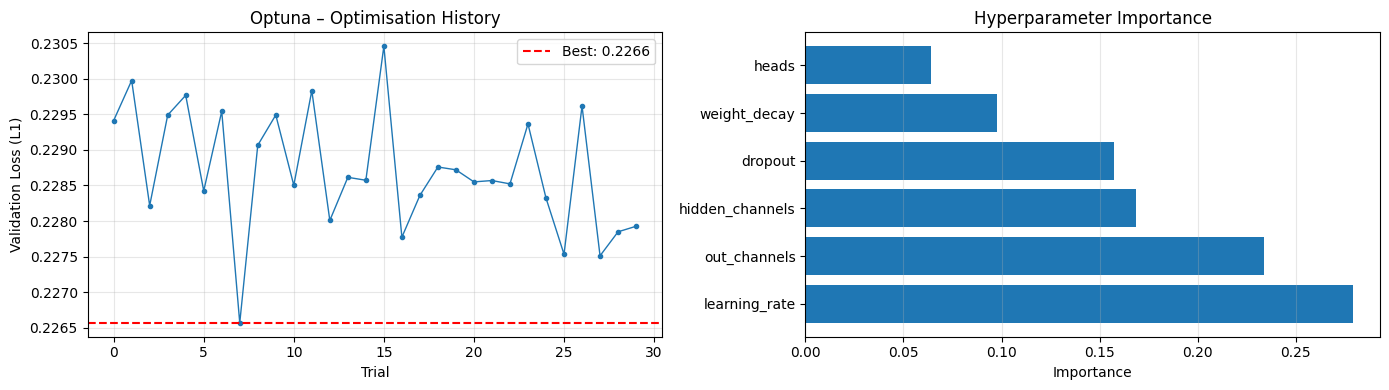


Retraining with best hyperparameters (full patience / epochs)…
Removing existing model at: best_gat_optuna_model.pt
Epoch 1/500, Train Loss: 0.2408, Val Loss: 0.2345
Validation loss decreased (0.234479 --> 0.234479).  Saving model ...
Epoch 2/500, Train Loss: 0.2409, Val Loss: 0.2337
Validation loss decreased (0.234479 --> 0.233680).  Saving model ...
Epoch 3/500, Train Loss: 0.2404, Val Loss: 0.2341
Epoch 4/500, Train Loss: 0.2406, Val Loss: 0.2339
Epoch 5/500, Train Loss: 0.2399, Val Loss: 0.2341
Epoch 6/500, Train Loss: 0.2398, Val Loss: 0.2334
Validation loss decreased (0.233680 --> 0.233372).  Saving model ...
Epoch 7/500, Train Loss: 0.2390, Val Loss: 0.2337
Epoch 8/500, Train Loss: 0.2388, Val Loss: 0.2326
Validation loss decreased (0.233372 --> 0.232650).  Saving model ...
Epoch 9/500, Train Loss: 0.2382, Val Loss: 0.2335
Epoch 10/500, Train Loss: 0.2375, Val Loss: 0.2297
Validation loss decreased (0.232650 --> 0.229665).  Saving model ...
Epoch 11/500, Train Loss: 0.2379, Val

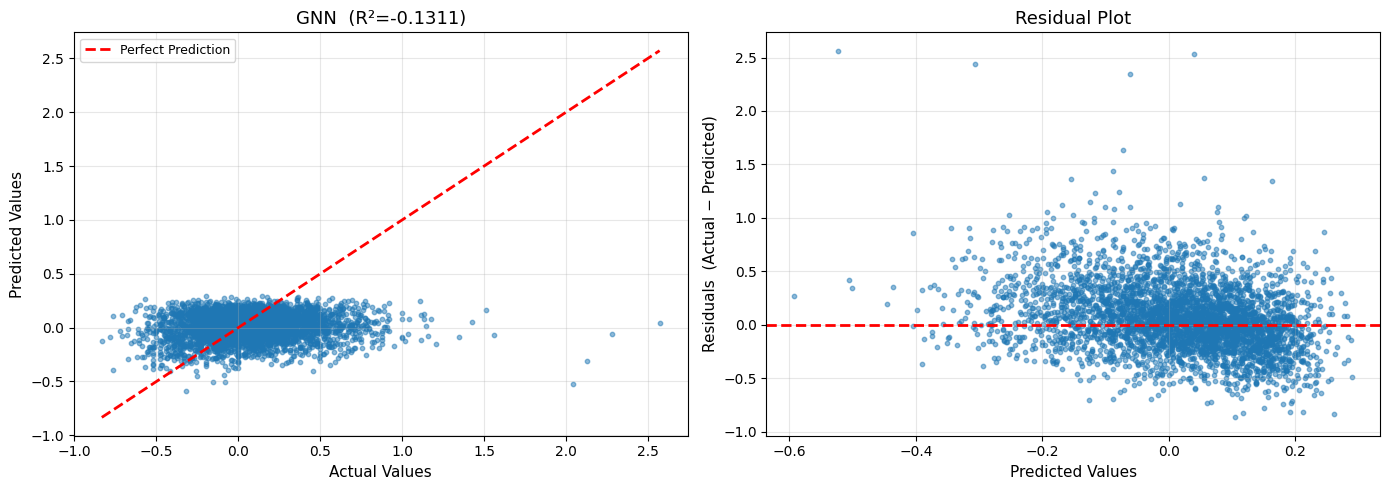

In [ ]:
import warnings

warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)

# ── Optuna Hyperparameter Tuning ──────────────────────────────────────────────
# Hyperparameters searched:
#   hidden_channels  : width of internal GATv2 layers
#   out_channels     : output dim of the second GATv2 layer
#   heads            : number of attention heads
#   dropout          : dropout rate (GATv2 + MLP)
#   learning_rate    : Adam LR
#   weight_decay     : Adam L2 regularisation

N_TRIALS = 30  # increase for a more thorough search
MAX_EPOCHS = 150  # epochs per trial (early-stopping can cut this short)
PATIENCE = 20  # early-stopping patience during tuning


def objective(trial: optuna.Trial) -> float:
    """Return best validation loss for a given set of hyperparameters."""

    # ── Sample hyperparameters ────────────────────────────────────────────────
    hidden_channels = trial.suggest_int("hidden_channels", 16, 512, step=64)
    out_channels = trial.suggest_int("out_channels", 64, 512, step=64)
    heads = trial.suggest_int("heads", 1, 8)
    dropout = trial.suggest_float("dropout", 0.0, 0.4, step=0.1)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

    # ── Build model ───────────────────────────────────────────────────────────
    _in_channels = data_dict[2006].num_node_features
    _scalar_dim = data_dict[2006].scalar.shape[1]

    _model = GATNet(
        in_channels=_in_channels,
        out_channels=out_channels,
        scalar_dim=_scalar_dim,
        hidden_channels=hidden_channels,
        heads=heads,
        dropout=dropout,
    ).to(device)

    _optimizer = optim.Adam(
        _model.parameters(), lr=learning_rate, weight_decay=weight_decay
    )
    _criterion = nn.L1Loss().to(device)

    # Use a trial-specific checkpoint path so parallel trials don't collide
    ckpt_path = f"optuna_trial_{trial.number}.pt"
    _early_stopper = EarlyStopping(
        patience=PATIENCE,
        min_delta=0.0001,
        path=ckpt_path,
        printing=False,  # suppress per-epoch output during tuning
    )

    # ── Train ─────────────────────────────────────────────────────────────────
    train_model(
        MAX_EPOCHS,
        _model,
        _optimizer,
        _criterion,
        train_loader,
        val_loader,
        _early_stopper,
        device,
        printing=False,
    )

    best_val_loss = _early_stopper.best_loss

    # Report to Optuna and allow pruning at the end of training
    trial.report(best_val_loss, step=MAX_EPOCHS)

    # Clean up the checkpoint file
    if os.path.exists(ckpt_path):
        os.remove(ckpt_path)

    return best_val_loss


# ── Run study ─────────────────────────────────────────────────────────────────
sampler = TPESampler(seed=42)
study = optuna.create_study(
    direction="minimize",
    sampler=sampler,
    study_name="GNN",
    storage="sqlite:///gnn.db",
    load_if_exists=False,
)

optuna.logging.set_verbosity(optuna.logging.WARNING)  # keep output clean

print(f"Starting Optuna search: {N_TRIALS} trials, up to {MAX_EPOCHS} epochs each.")
print("=" * 60)

study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True,
)

# ── Results ───────────────────────────────────────────────────────────────────
best = study.best_trial
print("\n" + "=" * 60)
print(f"Best trial: #{best.number}  (val loss = {best.value:.6f})")
print("Best hyperparameters:")
for k, v in best.params.items():
    print(f"  {k:20s}: {v}")

# Store best params for easy access in subsequent cells
best_params = best.params

# ── Plot optimisation history ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Optimisation history
values = [t.value for t in study.trials]
axes[0].plot(values, marker="o", linewidth=1, markersize=3)
axes[0].axhline(best.value, color="r", linestyle="--", label=f"Best: {best.value:.4f}")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Validation Loss (L1)")
axes[0].set_title("Optuna – Optimisation History")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Parameter importance (requires scikit-learn)
try:
    importances = optuna.importance.get_param_importances(study)
    axes[1].barh(list(importances.keys()), list(importances.values()))
    axes[1].set_xlabel("Importance")
    axes[1].set_title("Hyperparameter Importance")
    axes[1].grid(True, alpha=0.3, axis="x")
except Exception:
    axes[1].text(
        0.5,
        0.5,
        "Install scikit-learn\nfor importance plot",
        ha="center",
        va="center",
        transform=axes[1].transAxes,
    )

plt.tight_layout()
plt.show()



Retraining with best hyperparameters (full patience / epochs)…
Removing existing model at: pt_models/best_gnn.pt
Epoch 1/500, Train Loss: 0.2419, Val Loss: 0.2361
Validation loss decreased (0.236138 --> 0.236138).  Saving model ...
Epoch 2/500, Train Loss: 0.2472, Val Loss: 0.2354
Validation loss decreased (0.236138 --> 0.235371).  Saving model ...
Epoch 3/500, Train Loss: 0.2409, Val Loss: 0.2354
Epoch 4/500, Train Loss: 0.2407, Val Loss: 0.2354
Epoch 5/500, Train Loss: 0.2405, Val Loss: 0.2351
Validation loss decreased (0.235371 --> 0.235102).  Saving model ...
Epoch 6/500, Train Loss: 0.2408, Val Loss: 0.2352
Epoch 7/500, Train Loss: 0.2409, Val Loss: 0.2347
Validation loss decreased (0.235102 --> 0.234682).  Saving model ...
Epoch 8/500, Train Loss: 0.2407, Val Loss: 0.2351
Epoch 9/500, Train Loss: 0.2403, Val Loss: 0.2343
Validation loss decreased (0.234682 --> 0.234272).  Saving model ...
Epoch 10/500, Train Loss: 0.2399, Val Loss: 0.2344
Epoch 11/500, Train Loss: 0.2400, Val Lo

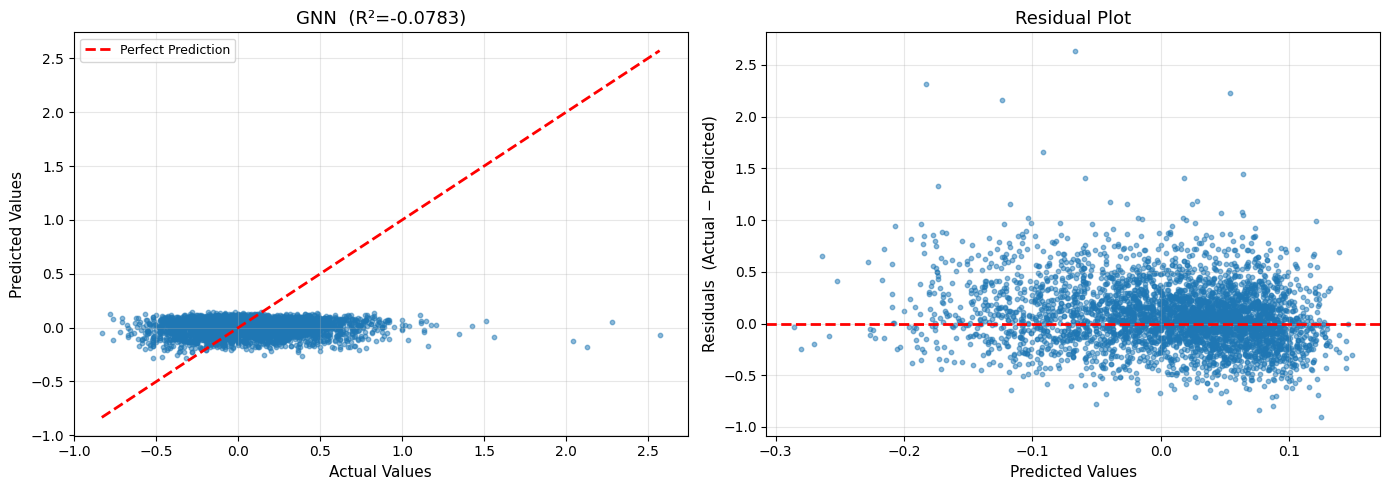

In [22]:
study = optuna.load_study(
    study_name="GNN",
    storage="sqlite:///gnn.db",
)

best_params = study.best_params

# ── Retrain with best hyperparameters ─────────────────────────────────────────
print("\nRetraining with best hyperparameters (full patience / epochs)…")

in_channels = data_dict[2006].num_node_features
scalar_dim = data_dict[2006].scalar.shape[1]

best_model = GATNet(
    in_channels=in_channels,
    out_channels=best_params["out_channels"],
    scalar_dim=scalar_dim,
    hidden_channels=best_params["hidden_channels"],
    heads=best_params["heads"],
    dropout=best_params["dropout"],
).to(device)

best_optimizer = optim.Adam(
    best_model.parameters(),
    lr=best_params["learning_rate"],
    weight_decay=best_params["weight_decay"],
)
best_criterion = nn.L1Loss().to(device)
best_early_stopper = EarlyStopping(
    patience=50,
    min_delta=0.0001,
    path="pt_models/best_gnn.pt",
    printing=True,
)

train_losses, val_losses = train_model(
    500,
    best_model,
    best_optimizer,
    best_criterion,
    train_loader,
    val_loader,
    best_early_stopper,
    device,
    printing=True,
)


print("\nFinal validation evaluation with best Optuna model:")
all_outputs, all_targets, avg_correct = evaluation(
    best_model, val_loader, device, printing=True
)

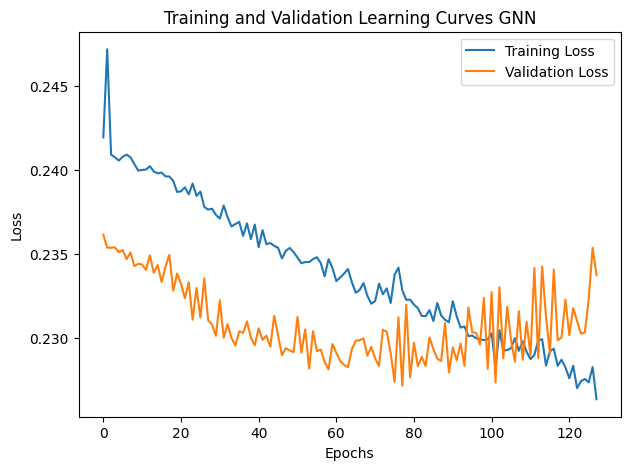

In [23]:
# plot loss curves
plt.figure(figsize=(7, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Learning Curves GNN")
plt.legend()
plt.show()

## Test Set Evaluation with baseline Comparison

Loading best model for evaluation...
Evaluating on test set...

MODEL: GNN
Number of predictions:            5684
Mean Squared Error (MSE):         0.089471
Root Mean Squared Error (RMSE):   0.299117
Mean Absolute Error (MAE):        0.227166
Median Absolute Error:            0.185147
Mean Absolute Percentage Error:   11926042.77%
R² Score:                         -0.025288

BASELINE: Previous Year's Score (Persistence)
Number of predictions:            4156
Mean Squared Error (MSE):         0.252137
Root Mean Squared Error (RMSE):   0.502133
Mean Absolute Error (MAE):        0.373026
Median Absolute Error:            0.281809
Mean Absolute Percentage Error:   52827555.36%
R² Score:                         -1.886821

BASELINE: Overall Mean (Global Historical Mean)
Number of predictions:            5684
Mean Squared Error (MSE):         0.088240
Root Mean Squared Error (RMSE):   0.297052
Mean Absolute Error (MAE):        0.226622
Median Absolute Error:            0.183740
Mean Absolute 

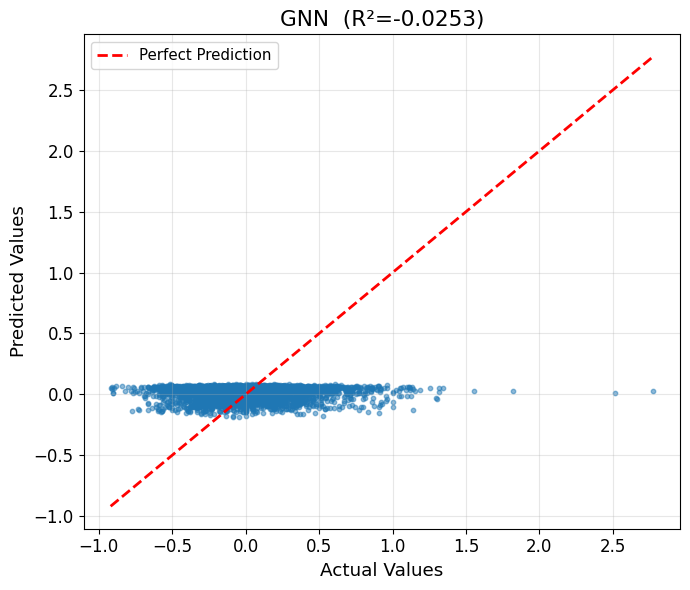

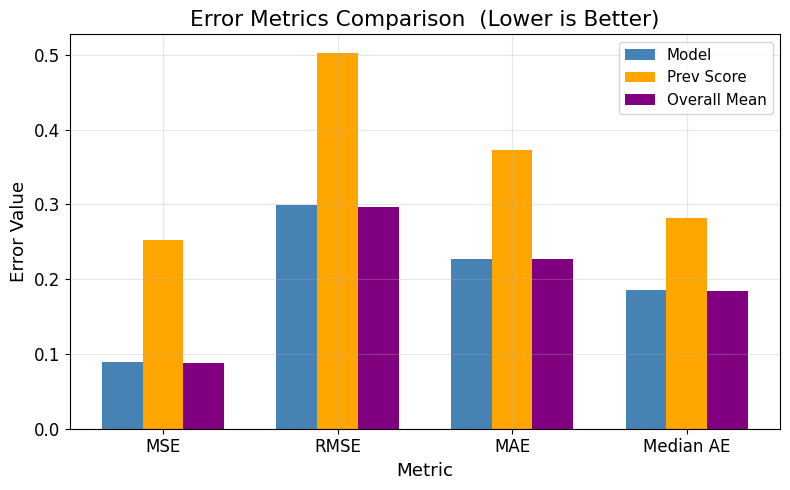

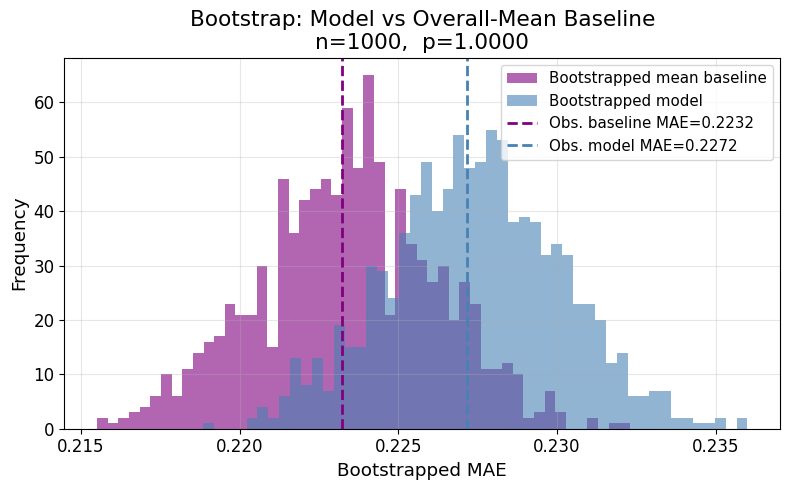

In [26]:
study = optuna.load_study(
    study_name="GNN",
    storage="sqlite:///gnn.db",
)

best_params = study.best_params

in_channels = data_dict[2006].num_node_features
scalar_dim = data_dict[2006].scalar.shape[1]  # Automatically detect scalar features
out_channels = best_params["out_channels"]
hidden_channels = best_params["hidden_channels"]
heads = best_params["heads"]
dropout = best_params["dropout"]

model = GATNet(
    in_channels, out_channels, scalar_dim, hidden_channels, heads, dropout
).to(device)

# Evaluate on test set and compare with baselines
print("Loading best model for evaluation...")
model.load_state_dict(torch.load("pt_models/best_gnn.pt", map_location=device))

print("Evaluating on test set...")

# Run evaluation with baseline comparisons
results = evaluate_gnn(
    model=model,
    test_loader=test_loader,
    data_dict=data_dict,
    test_years=test_years,
    compare_baselines=True,
    device=device,
    printing=True,
    export=True,
    export_dir="gnn_export",
    font_scale=1.2,
)